# Semantic Regression Report Comparison

This notebook compares the two runs under `results/semantic_regression`:
- `2026-03-27_12-35-02_KRR_cosine_50ep`
- `original_KRR_l2_50ep`

It visualizes differences in:
- R2
- Category and word accuracies
- Bias behavior (top-1 concentration, entropy, prediction diversity)

Across:
- Aggregate
- Patient level
- Embedding model level

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur] + list(cur.parents):
        if (candidate / "results" / "semantic_regression").exists():
            return candidate
    raise FileNotFoundError("Could not locate results/semantic_regression from current working directory")

repo_root = find_repo_root(Path.cwd())
results_root = repo_root / "results" / "semantic_regression"

run_map = {
    "cosine": results_root / "2026-03-27_12-35-02_KRR_cosine_50ep" / "report",
    "l2": results_root / "original_KRR_l2_50ep" / "report",
}

for run, path in run_map.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing report directory for {run}: {path}")

output_dir = results_root / "comparison_figures"
output_dir.mkdir(parents=True, exist_ok=True)

repo_root, results_root, output_dir

(WindowsPath('D:/OneDrive - Northwestern University/PycharmProjects/Speech/main'),
 WindowsPath('D:/OneDrive - Northwestern University/PycharmProjects/Speech/main/results/semantic_regression'),
 WindowsPath('D:/OneDrive - Northwestern University/PycharmProjects/Speech/main/results/semantic_regression/comparison_figures'))

In [2]:
def load_run_csv(run_label: str, filename: str) -> pd.DataFrame:
    df = pd.read_csv(run_map[run_label] / filename)
    df["run"] = run_label
    return df

metric_df = pd.concat([
    load_run_csv("cosine", "metric_dissociation.csv"),
    load_run_csv("l2", "metric_dissociation.csv"),
], ignore_index=True)

sig_df = pd.concat([
    load_run_csv("cosine", "null_corrected_significance.csv"),
    load_run_csv("l2", "null_corrected_significance.csv"),
], ignore_index=True)

bias_df = pd.concat([
    load_run_csv("cosine", "word_prediction_bias.csv"),
    load_run_csv("l2", "word_prediction_bias.csv"),
], ignore_index=True)

print("Rows loaded:")
print({
    "metric_dissociation": len(metric_df),
    "null_corrected_significance": len(sig_df),
    "word_prediction_bias": len(bias_df),
})

print("\nPer run counts (expected 72 rows/run/file):")
print(metric_df.groupby("run").size())
print(sig_df.groupby("run").size())
print(bias_df.groupby("run").size())

Rows loaded:
{'metric_dissociation': 144, 'null_corrected_significance': 144, 'word_prediction_bias': 144}

Per run counts (expected 72 rows/run/file):
run
cosine    72
l2        72
dtype: int64
run
cosine    72
l2        72
dtype: int64
run
cosine    72
l2        72
dtype: int64


In [3]:
# Build paired comparison tables on patient x embedding keys.
key_cols = ["patient", "embedding"]

metric_pair = (
    metric_df[metric_df["run"] == "cosine"].drop(columns=["run"])
    .merge(
        metric_df[metric_df["run"] == "l2"].drop(columns=["run"]),
        on=key_cols,
        suffixes=("_cosine", "_l2"),
        how="inner",
    )
)

bias_pair = (
    bias_df[bias_df["run"] == "cosine"].drop(columns=["run"])
    .merge(
        bias_df[bias_df["run"] == "l2"].drop(columns=["run"]),
        on=key_cols,
        suffixes=("_cosine", "_l2"),
        how="inner",
    )
)

sig_df = sig_df.copy()
sig_df["cat_significant"] = sig_df["cat_sig"].ne("NS")
sig_df["word_significant"] = sig_df["word_sig"].ne("NS")

for base_col in ["best_r2", "best_cat_acc", "best_word_acc"]:
    metric_pair[f"delta_{base_col}"] = metric_pair[f"{base_col}_cosine"] - metric_pair[f"{base_col}_l2"]

for base_col in ["top1_frac", "n_unique_pred", "pred_entropy_norm"]:
    bias_pair[f"delta_{base_col}"] = bias_pair[f"{base_col}_cosine"] - bias_pair[f"{base_col}_l2"]

print(f"Paired rows: metrics={len(metric_pair)}, bias={len(bias_pair)}")
metric_pair.head(3)

Paired rows: metrics=72, bias=72


,patient,embedding,r2_best_bin_cosine,cat_best_bin_cosine,word_best_bin_cosine,best_r2_cosine,best_cat_acc_cosine,best_word_acc_cosine,r2_best_bin_l2,cat_best_bin_l2,word_best_bin_l2,best_r2_l2,best_cat_acc_l2,best_word_acc_l2,delta_best_r2,delta_best_cat_acc,delta_best_word_acc
0,AA,GloVe,21,21,21,0.037108,0.332449,0.050089,21,19,15,0.039324,0.304054,0.032715,-0.002216,0.028395,0.017374
1,AA,FastText,21,19,21,0.029047,0.325699,0.041387,21,21,21,0.028481,0.254809,0.029751,0.000566,0.070890,0.011636
2,AA,Word2Vec,21,20,21,0.032820,0.358863,0.049516,20,20,20,0.032969,0.275712,0.031406,-0.000149,0.083150,0.018110


,run,best_r2,best_cat_acc,best_word_acc
0,cosine,0.013405,0.275691,0.040006
1,l2,0.013643,0.191865,0.024553


,run,top1_frac,n_unique_pred,pred_entropy_norm
0,cosine,0.100001,62.347222,0.873124
1,l2,0.537692,17.597222,0.340902


,run,cat_sig_rate,word_sig_rate
0,cosine,1.000000,0.958333
1,l2,0.736111,0.555556


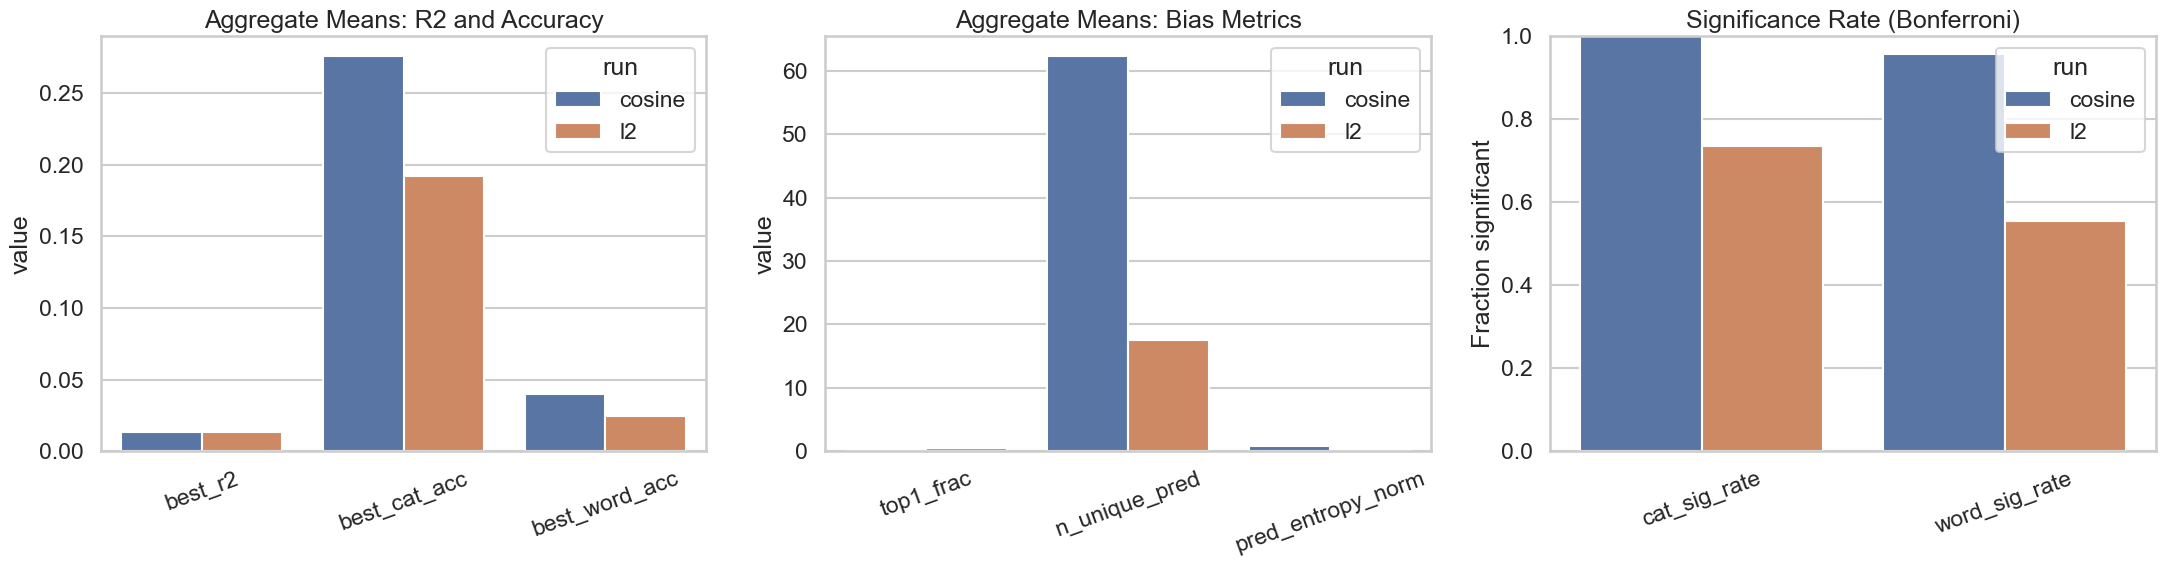

In [4]:
# Aggregate dashboard: R2, category/word accuracy, and bias summary.
agg_metrics = metric_df.groupby("run")[["best_r2", "best_cat_acc", "best_word_acc"]].mean().reset_index()
agg_bias = bias_df.groupby("run")[["top1_frac", "n_unique_pred", "pred_entropy_norm"]].mean().reset_index()

sig_overall = (
    sig_df.groupby("run")[["cat_significant", "word_significant"]]
    .mean()
    .rename(columns={"cat_significant": "cat_sig_rate", "word_significant": "word_sig_rate"})
    .reset_index()
)

display(agg_metrics)
display(agg_bias)
display(sig_overall)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

m_long = agg_metrics.melt(id_vars="run", var_name="metric", value_name="value")
sns.barplot(data=m_long, x="metric", y="value", hue="run", ax=axes[0])
axes[0].set_title("Aggregate Means: R2 and Accuracy")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

b_long = agg_bias.melt(id_vars="run", var_name="metric", value_name="value")
sns.barplot(data=b_long, x="metric", y="value", hue="run", ax=axes[1])
axes[1].set_title("Aggregate Means: Bias Metrics")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

s_long = sig_overall.melt(id_vars="run", var_name="metric", value_name="rate")
sns.barplot(data=s_long, x="metric", y="rate", hue="run", ax=axes[2])
axes[2].set_ylim(0, 1)
axes[2].set_title("Significance Rate (Bonferroni)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Fraction significant")
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    if ax.legend_ is not None:
        ax.legend(title="run", loc="best")

fig.tight_layout()
fig.savefig(output_dir / "aggregate_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

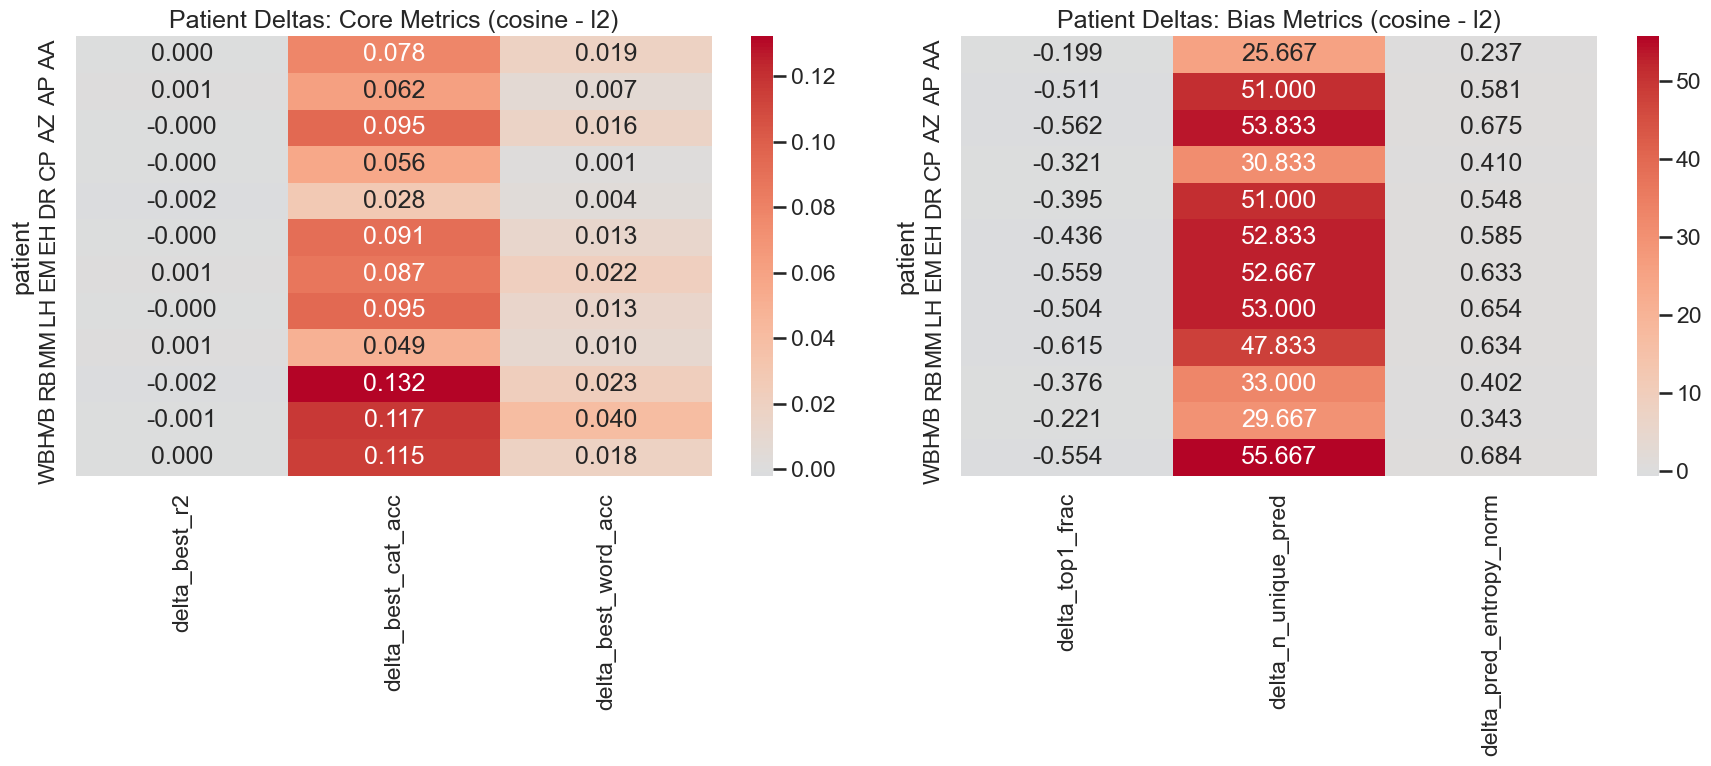

,patient,run,cat_significant,word_significant
0,AA,cosine,1.000000,1.000000
1,AA,l2,0.833333,0.833333
2,AP,cosine,1.000000,0.833333
3,AP,l2,0.500000,0.500000
4,AZ,cosine,1.000000,1.000000
5,AZ,l2,0.833333,0.166667
6,CP,cosine,1.000000,1.000000
7,CP,l2,0.333333,0.500000
8,DR,cosine,1.000000,0.666667
9,DR,l2,0.500000,0.166667


In [5]:
# Patient-level breakdown via delta heatmaps (cosine - l2).
patient_metric_delta = metric_pair.groupby("patient")[["delta_best_r2", "delta_best_cat_acc", "delta_best_word_acc"]].mean()
patient_bias_delta = bias_pair.groupby("patient")[["delta_top1_frac", "delta_n_unique_pred", "delta_pred_entropy_norm"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(patient_metric_delta.sort_index(), cmap="coolwarm", center=0, annot=True, fmt=".3f", ax=axes[0])
axes[0].set_title("Patient Deltas: Core Metrics (cosine - l2)")

sns.heatmap(patient_bias_delta.sort_index(), cmap="coolwarm", center=0, annot=True, fmt=".3f", ax=axes[1])
axes[1].set_title("Patient Deltas: Bias Metrics (cosine - l2)")

fig.tight_layout()
fig.savefig(output_dir / "patient_delta_heatmaps.png", dpi=180, bbox_inches="tight")
plt.show()

patient_sig = sig_df.groupby(["patient", "run"])[["cat_significant", "word_significant"]].mean().reset_index()
display(patient_sig.sort_values(["patient", "run"]))

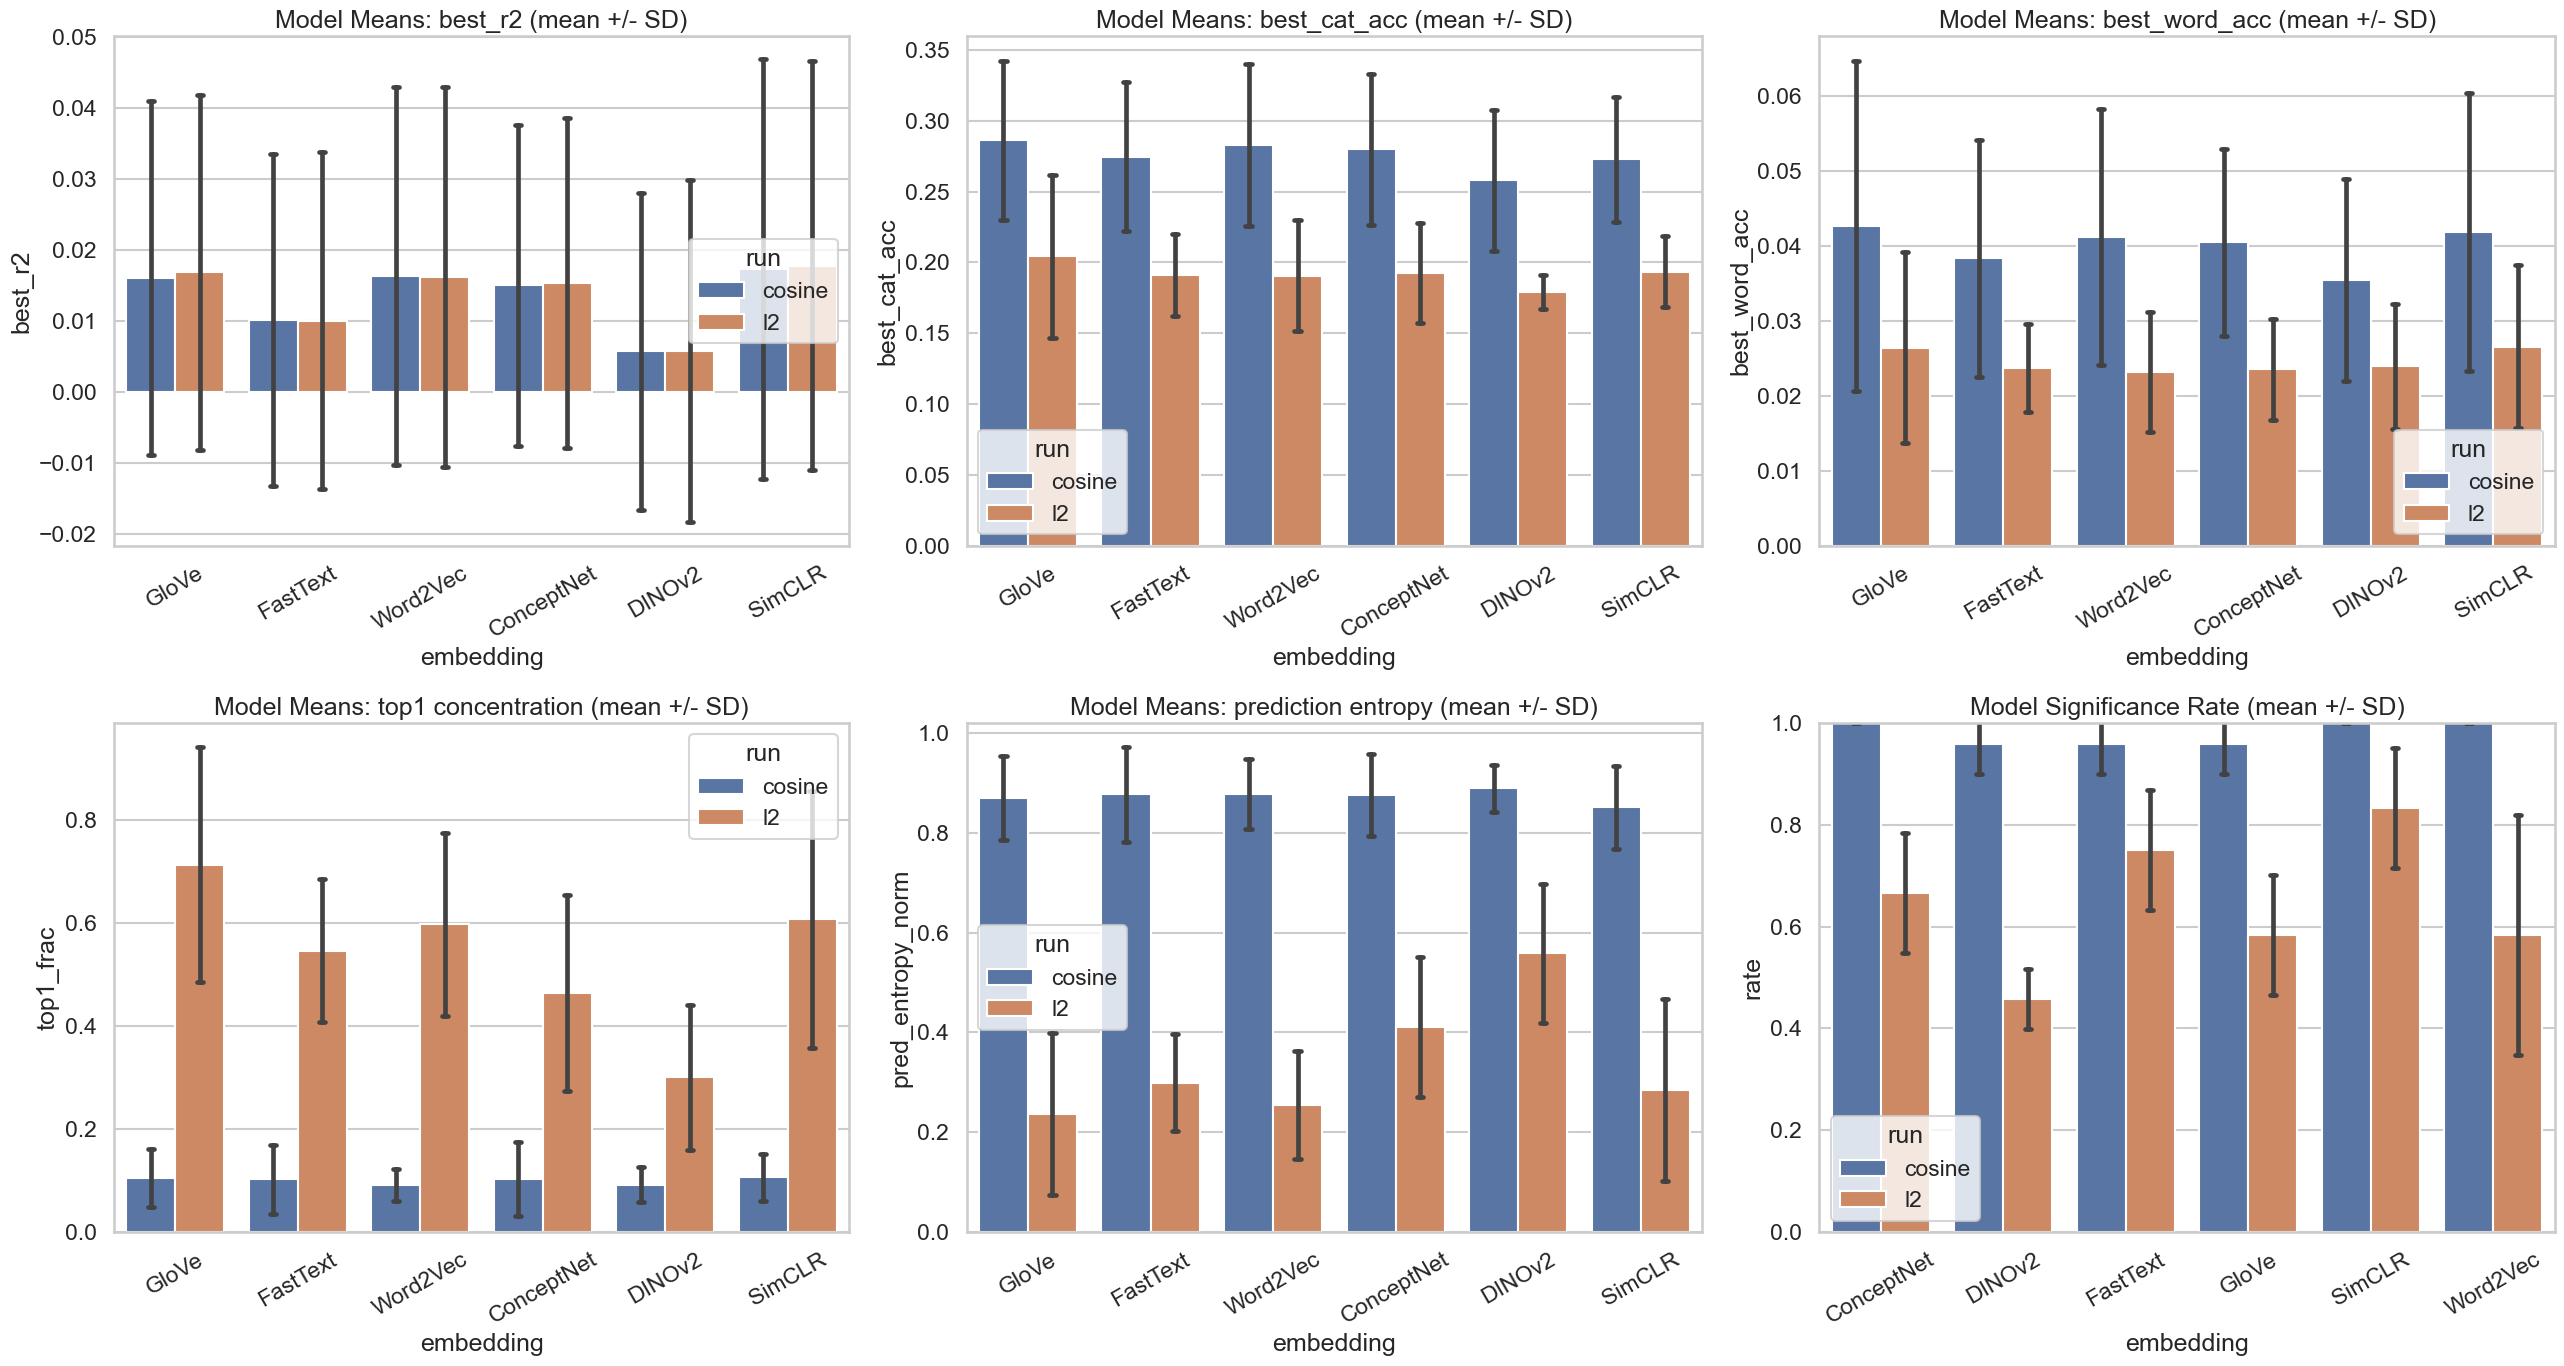

In [14]:
# Model-level breakdown (embedding models) with separate category and word accuracy panels.
model_metrics = metric_df.groupby(["embedding", "run"])[["best_r2", "best_cat_acc", "best_word_acc"]].mean().reset_index()
model_bias = bias_df.groupby(["embedding", "run"])[["top1_frac", "pred_entropy_norm", "n_unique_pred"]].mean().reset_index()
model_sig = sig_df.groupby(["embedding", "run"])[["cat_significant", "word_significant"]].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(26, 14))

sns.barplot(
    data=metric_df, x="embedding", y="best_r2", hue="run",
    estimator=np.mean, errorbar="sd", capsize=0.1, ax=axes[0, 0]
 )
axes[0, 0].set_title("Model Means: best_r2 (mean +/- SD)")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=metric_df, x="embedding", y="best_cat_acc", hue="run",
    estimator=np.mean, errorbar="sd", capsize=0.1, ax=axes[0, 1]
 )
axes[0, 1].set_title("Model Means: best_cat_acc (mean +/- SD)")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(
    data=metric_df, x="embedding", y="best_word_acc", hue="run",
    estimator=np.mean, errorbar="sd", capsize=0.1, ax=axes[0, 2]
 )
axes[0, 2].set_title("Model Means: best_word_acc (mean +/- SD)")
axes[0, 2].tick_params(axis="x", rotation=30)

sns.barplot(
    data=bias_df, x="embedding", y="top1_frac", hue="run",
    estimator=np.mean, errorbar="sd", capsize=0.1, ax=axes[1, 0]
 )
axes[1, 0].set_title("Model Means: top1 concentration (mean +/- SD)")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=bias_df, x="embedding", y="pred_entropy_norm", hue="run",
    estimator=np.mean, errorbar="sd", capsize=0.1, ax=axes[1, 1]
 )
axes[1, 1].set_title("Model Means: prediction entropy (mean +/- SD)")
axes[1, 1].tick_params(axis="x", rotation=30)

sig_long = model_sig.melt(id_vars=["embedding", "run"], value_vars=["cat_significant", "word_significant"], var_name="metric", value_name="rate")
sns.barplot(
    data=sig_long, x="embedding", y="rate", hue="run",
    estimator=np.mean, errorbar="sd", capsize=0.1, ax=axes[1, 2]
 )
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title("Model Significance Rate (mean +/- SD)")
axes[1, 2].tick_params(axis="x", rotation=30)

for ax in axes.flat:
    ax.legend(title="run", loc="best")

fig.tight_layout()
fig.savefig(output_dir / "model_level_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

In [13]:
# Statistical significance checks: cosine vs l2 (paired over patient x embedding rows).
def benjamini_hochberg(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adjusted = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adjusted[i] = prev
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adjusted, 0, 1)
    return out

def paired_tests(df, metric, cosine_col, l2_col, group_cols=None):
    if group_cols is None:
        group_cols = []

    rows = []
    grouped = [([], df)] if not group_cols else list(df.groupby(group_cols, dropna=False))
    for key, g in grouped:
        x = g[cosine_col].to_numpy(dtype=float)
        y = g[l2_col].to_numpy(dtype=float)
        delta = x - y

        w_stat, w_p = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided", method="auto")
        t_stat, t_p = ttest_rel(x, y, nan_policy="omit")

        if not isinstance(key, tuple):
            key = (key,) if group_cols else tuple()

        row = {
            "metric": metric,
            "n": len(g),
            "mean_cosine": float(np.mean(x)),
            "mean_l2": float(np.mean(y)),
            "mean_delta": float(np.mean(delta)),
            "std_delta": float(np.std(delta, ddof=1)) if len(delta) > 1 else np.nan,
            "wilcoxon_stat": float(w_stat),
            "wilcoxon_p": float(w_p),
            "ttest_stat": float(t_stat),
            "ttest_p": float(t_p),
        }
        for i, col in enumerate(group_cols):
            row[col] = key[i]
        rows.append(row)

    out = pd.DataFrame(rows)
    if not out.empty:
        out["wilcoxon_p_fdr_bh"] = benjamini_hochberg(out["wilcoxon_p"].to_numpy())
        out["ttest_p_fdr_bh"] = benjamini_hochberg(out["ttest_p"].to_numpy())
    return out

metric_specs = [
    ("best_r2", metric_pair, "best_r2_cosine", "best_r2_l2"),
    ("best_cat_acc", metric_pair, "best_cat_acc_cosine", "best_cat_acc_l2"),
    ("best_word_acc", metric_pair, "best_word_acc_cosine", "best_word_acc_l2"),
    ("top1_frac", bias_pair, "top1_frac_cosine", "top1_frac_l2"),
    ("pred_entropy_norm", bias_pair, "pred_entropy_norm_cosine", "pred_entropy_norm_l2"),
    ("n_unique_pred", bias_pair, "n_unique_pred_cosine", "n_unique_pred_l2"),
]

overall_stats = pd.concat([
    paired_tests(df, metric, col_c, col_l2)
    for metric, df, col_c, col_l2 in metric_specs
], ignore_index=True)

per_embedding_stats = pd.concat([
    paired_tests(df, metric, col_c, col_l2, group_cols=["embedding"])
    for metric, df, col_c, col_l2 in metric_specs
], ignore_index=True)

display_cols = [
    "metric", "n", "mean_cosine", "mean_l2", "mean_delta",
    "wilcoxon_p", "wilcoxon_p_fdr_bh", "ttest_p", "ttest_p_fdr_bh",
]

print("Overall paired significance (cosine vs l2):")
display(overall_stats[display_cols].sort_values("wilcoxon_p"))

print("Per-embedding paired significance (cosine vs l2):")
display(
    per_embedding_stats[["embedding"] + display_cols]
    .sort_values(["metric", "wilcoxon_p"])
    .reset_index(drop=True)
)

overall_stats.to_csv(output_dir / "stats_significance_overall.csv", index=False)
per_embedding_stats.to_csv(output_dir / "stats_significance_by_embedding.csv", index=False)
print(f"Saved stats tables to: {output_dir}")

Overall paired significance (cosine vs l2):


,metric,n,mean_cosine,mean_l2,mean_delta,wilcoxon_p,wilcoxon_p_fdr_bh,ttest_p,ttest_p_fdr_bh
5,n_unique_pred,72,62.347222,17.597222,44.750000,1.636311e-13,1.636311e-13,3.173672e-40,3.173672e-40
1,best_cat_acc,72,0.275691,0.191865,0.083826,1.658752e-13,1.658752e-13,7.584693e-31,7.584693e-31
4,pred_entropy_norm,72,0.873124,0.340902,0.532221,1.658752e-13,1.658752e-13,5.999062e-34,5.999062e-34
3,top1_frac,72,0.100001,0.537692,-0.437691,1.730075e-13,1.730075e-13,9.853470e-25,9.853470e-25
2,best_word_acc,72,0.040006,0.024553,0.015453,1.310643e-12,1.310643e-12,1.206175e-17,1.206175e-17
0,best_r2,72,0.013405,0.013643,-0.000238,6.615950e-01,6.615950e-01,2.865564e-01,2.865564e-01


Per-embedding paired significance (cosine vs l2):


,embedding,metric,n,mean_cosine,mean_l2,mean_delta,wilcoxon_p,wilcoxon_p_fdr_bh,ttest_p,ttest_p_fdr_bh
0,ConceptNet,best_cat_acc,12,0.279945,0.192555,0.087390,0.000488,0.000488,8.680347e-07,4.963801e-06
1,DINOv2,best_cat_acc,12,0.257861,0.179194,0.078666,0.000488,0.000488,7.588544e-05,7.588544e-05
2,FastText,best_cat_acc,12,0.274686,0.191077,0.083608,0.000488,0.000488,1.459319e-05,1.751182e-05
3,GloVe,best_cat_acc,12,0.286275,0.204223,0.082052,0.000488,0.000488,4.827540e-06,9.655081e-06
4,SimCLR,best_cat_acc,12,0.272707,0.193494,0.079212,0.000488,0.000488,6.595114e-06,9.892671e-06
5,Word2Vec,best_cat_acc,12,0.282676,0.190647,0.092029,0.000488,0.000488,1.654600e-06,4.963801e-06
6,GloVe,best_r2,12,0.016007,0.016826,-0.000819,0.092285,0.553711,9.474094e-02,5.684456e-01
7,FastText,best_r2,12,0.010101,0.010029,0.000072,0.733398,1.000000,7.408390e-01,9.255762e-01
8,SimCLR,best_r2,12,0.017286,0.017759,-0.000473,0.733398,1.000000,5.277366e-01,9.255762e-01
9,ConceptNet,best_r2,12,0.015012,0.015377,-0.000365,0.909668,1.000000,5.215500e-01,9.255762e-01


Saved stats tables to: D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\results\semantic_regression\comparison_figures


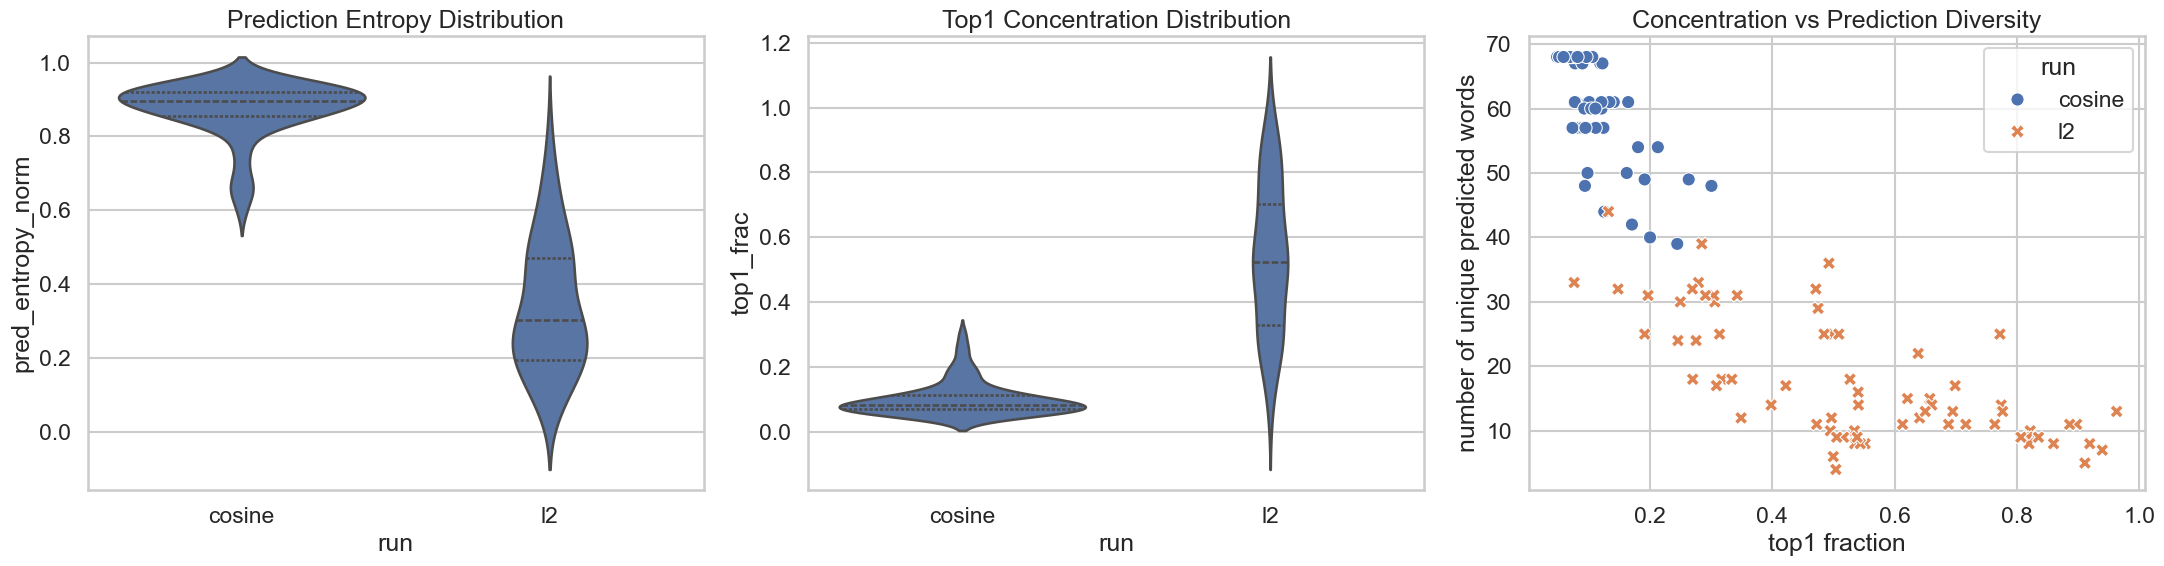

,run,embedding,top1_word,count
0,cosine,ConceptNet,apple,1
1,cosine,DINOv2,banana,1
2,cosine,FastText,bat(animal),2
3,cosine,GloVe,bat(animal),1
4,cosine,SimCLR,crane,2
5,cosine,Word2Vec,train,3
6,l2,ConceptNet,lung,5
7,l2,DINOv2,cat,3
8,l2,FastText,book,6
9,l2,GloVe,saw,8


In [7]:
# Bias deep-dive: entropy, concentration, and diversity relationships.
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.violinplot(data=bias_df, x="run", y="pred_entropy_norm", inner="quartile", ax=axes[0])
axes[0].set_title("Prediction Entropy Distribution")

sns.violinplot(data=bias_df, x="run", y="top1_frac", inner="quartile", ax=axes[1])
axes[1].set_title("Top1 Concentration Distribution")

sns.scatterplot(data=bias_df, x="top1_frac", y="n_unique_pred", hue="run", style="run", s=90, ax=axes[2])
axes[2].set_title("Concentration vs Prediction Diversity")
axes[2].set_xlabel("top1 fraction")
axes[2].set_ylabel("number of unique predicted words")

fig.tight_layout()
fig.savefig(output_dir / "bias_analysis.png", dpi=180, bbox_inches="tight")
plt.show()

bias_top_words = (
    bias_df.groupby(["run", "embedding", "top1_word"]).size()
    .reset_index(name="count")
    .sort_values(["run", "embedding", "count"], ascending=[True, True, False])
)

top_words_by_model = bias_top_words.groupby(["run", "embedding"]).head(1).reset_index(drop=True)
top_words_by_model

In [8]:
# Compact comparison table for direct reporting.
summary_table = pd.DataFrame({
    "run": ["cosine", "l2"],
    "mean_best_r2": [
        metric_df.query("run == 'cosine'")["best_r2"].mean(),
        metric_df.query("run == 'l2'")["best_r2"].mean(),
    ],
    "mean_best_cat_acc": [
        metric_df.query("run == 'cosine'")["best_cat_acc"].mean(),
        metric_df.query("run == 'l2'")["best_cat_acc"].mean(),
    ],
    "mean_best_word_acc": [
        metric_df.query("run == 'cosine'")["best_word_acc"].mean(),
        metric_df.query("run == 'l2'")["best_word_acc"].mean(),
    ],
    "cat_significant_count": [
        int(sig_df.query("run == 'cosine'")["cat_significant"].sum()),
        int(sig_df.query("run == 'l2'")["cat_significant"].sum()),
    ],
    "word_significant_count": [
        int(sig_df.query("run == 'cosine'")["word_significant"].sum()),
        int(sig_df.query("run == 'l2'")["word_significant"].sum()),
    ],
    "mean_top1_frac": [
        bias_df.query("run == 'cosine'")["top1_frac"].mean(),
        bias_df.query("run == 'l2'")["top1_frac"].mean(),
    ],
    "mean_pred_entropy_norm": [
        bias_df.query("run == 'cosine'")["pred_entropy_norm"].mean(),
        bias_df.query("run == 'l2'")["pred_entropy_norm"].mean(),
    ],
    "mean_n_unique_pred": [
        bias_df.query("run == 'cosine'")["n_unique_pred"].mean(),
        bias_df.query("run == 'l2'")["n_unique_pred"].mean(),
    ],
})

display(summary_table)
summary_table.to_csv(output_dir / "summary_table.csv", index=False)
print(f"Saved plots and summary table to: {output_dir}")

,run,mean_best_r2,mean_best_cat_acc,mean_best_word_acc,cat_significant_count,word_significant_count,mean_top1_frac,mean_pred_entropy_norm,mean_n_unique_pred
0,cosine,0.013405,0.275691,0.040006,72,69,0.100001,0.873124,62.347222
1,l2,0.013643,0.191865,0.024553,53,40,0.537692,0.340902,17.597222


Saved plots and summary table to: D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\results\semantic_regression\comparison_figures
